# Stellar Object Classification

In [208]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# downloading the dataset from the given URL
import requests
from io import StringIO

url = "https://raw.githubusercontent.com/Cepheid-iith/Stellar-Object-Classification/refs/heads/main/sdss_public_training.csv"
headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10.14; rv:66.0) Gecko/20100101 Firefox/66.0"}
req = requests.get(url, headers=headers)
data = StringIO(req.text)

df = pd.read_csv(data)
# df.to_csv("soc_dataset.csv", index=False)

# Basic information about the dataset

In [210]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,plate,mjd,fiberid
0,1.237650e+18,172.905328,-1.539105,19.31536,18.42067,18.18626,18.09060,18.07058,1231,301,6,24,3.640050e+18,STAR,3233,54891,64
1,1.237650e+18,162.006541,0.831897,19.29348,17.90844,17.36041,17.13455,16.98703,756,301,5,308,2.881300e+18,STAR,2559,54208,460
2,1.237650e+18,198.881267,0.407531,19.40578,17.61941,16.70273,16.21548,15.85477,1334,301,4,15,3.322820e+17,GALAXY,295,51985,516
3,1.237650e+18,179.700240,-0.589650,18.19151,16.95824,17.03985,17.13071,17.20619,756,301,2,427,3.256190e+18,STAR,2892,54552,314
4,1.237650e+18,253.674045,61.671879,18.08931,18.05390,17.80788,17.72755,17.76427,1336,301,1,30,3.952880e+17,QSO,351,51695,352


In [211]:
df.shape

(8000, 17)

In [212]:
df.isnull().sum()

objid        0
ra           0
dec          0
u            0
g            0
r            0
i            0
z            0
run          0
rerun        0
camcol       0
field        0
specobjid    0
class        0
plate        0
mjd          0
fiberid      0
dtype: int64

In [213]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      8000 non-null   float64
 1   ra         8000 non-null   float64
 2   dec        8000 non-null   float64
 3   u          8000 non-null   float64
 4   g          8000 non-null   float64
 5   r          8000 non-null   float64
 6   i          8000 non-null   float64
 7   z          8000 non-null   float64
 8   run        8000 non-null   int64  
 9   rerun      8000 non-null   int64  
 10  camcol     8000 non-null   int64  
 11  field      8000 non-null   int64  
 12  specobjid  8000 non-null   float64
 13  class      8000 non-null   str    
 14  plate      8000 non-null   int64  
 15  mjd        8000 non-null   int64  
 16  fiberid    8000 non-null   int64  
dtypes: float64(9), int64(7), str(1)
memory usage: 1.0 MB


- what a great dataset! there is no null values.

In [214]:
# printting the unique values
print("Unique values in 'class' column:", df['class'].nunique())
print("Unique values in 'camcol' column:", df['camcol'].nunique())
print("Unique values in 'objid' column:", df['objid'].nunique())
print("Unique values in 'run' column:", df['run'].nunique())
print("Unique values in 'rerun' column:", df['rerun'].nunique())
print("Unique values in 'field' column:", df['field'].nunique())
print("Unique values in 'specobjid' column:", df['specobjid'].nunique())
print("Unique values in 'plate' column:", df['plate'].nunique())
print("Unique values in 'mjd' column:", df['mjd'].nunique())
print("Unique values in 'fiberid' column:", df['fiberid'].nunique())
print("Unique values in 'ra' column:", df['ra'].nunique())
print("Unique values in 'dec' column:", df['dec'].nunique())
print("Unique values in 'u' column:", df['u'].nunique())
print("Unique values in 'g' column:", df['g'].nunique())
print("Unique values in 'r' column:", df['r'].nunique())
print("Unique values in 'i' column:", df['i'].nunique())
print("Unique values in 'z' column:", df['z'].nunique())

Unique values in 'class' column: 3
Unique values in 'camcol' column: 6
Unique values in 'objid' column: 1
Unique values in 'run' column: 22
Unique values in 'rerun' column: 1
Unique values in 'field' column: 694
Unique values in 'specobjid' column: 5365
Unique values in 'plate' column: 477
Unique values in 'mjd' column: 351
Unique values in 'fiberid' column: 863
Unique values in 'ra' column: 8000
Unique values in 'dec' column: 8000
Unique values in 'u' column: 7825
Unique values in 'g' column: 7888
Unique values in 'r' column: 7914
Unique values in 'i' column: 7937
Unique values in 'z' column: 7928


**Observations:**
- Since the 'objid' and 'rerun' columns have only 1 unique value, they do not provide any useful information for classification and can be dropped from the dataset.
- The 'class' column has 3 unique values, which indicates that there are 3 different classes of stellar objects in the dataset. This is the target variable for classification.
- The columns 'specobjid' and 'fiberid' are removed because they are identifier-based metadata and do not represent physical properties of stellar objects. The columns 'run', 'camcol', 'field', 'plate', and 'mjd' are also dropped because they describe observation and instrument details rather than astrophysical characteristics. Removing these columns helps the model focus on the meaningful physical features needed for classification.

In [215]:
# Dropping zero variance features, identifier-based and observation metadata columns
df.drop(columns=['objid','rerun', 'specobjid','fiberid','run','camcol','field','plate','mjd'], inplace=True)
df.head()

,ra,dec,u,g,r,i,z,class
0,172.905328,-1.539105,19.31536,18.42067,18.18626,18.09060,18.07058,STAR
1,162.006541,0.831897,19.29348,17.90844,17.36041,17.13455,16.98703,STAR
2,198.881267,0.407531,19.40578,17.61941,16.70273,16.21548,15.85477,GALAXY
3,179.700240,-0.589650,18.19151,16.95824,17.03985,17.13071,17.20619,STAR
4,253.674045,61.671879,18.08931,18.05390,17.80788,17.72755,17.76427,QSO


### Univariate Exploratory Data Analysis

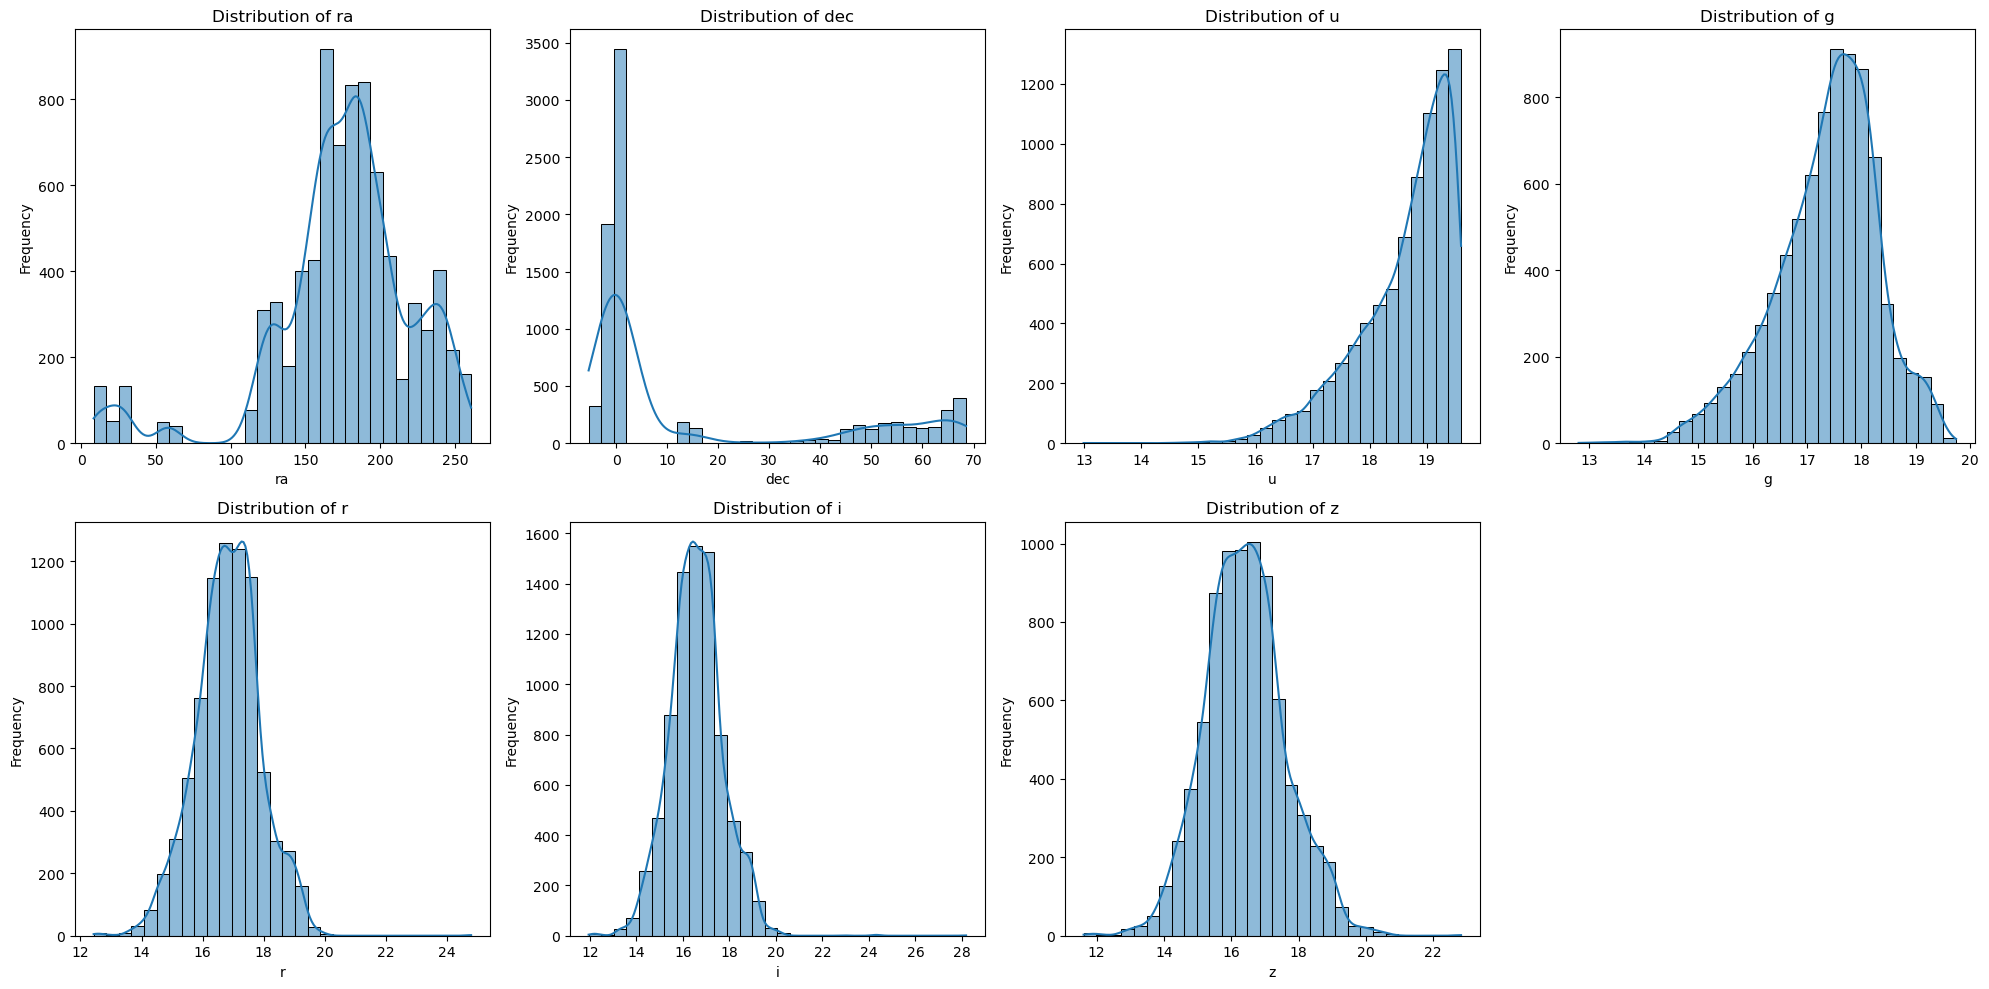

In [216]:
# plotting histograms for the features
features = ['ra', 'dec', 'u', 'g', 'r', 'i', 'z']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Plot histogram for each feature
for i, feature in enumerate(features):

    sns.histplot(data=df,x=feature,bins=30,kde=True,ax=axes[i])

    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Remove unused empty subplot
for j in range(len(features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

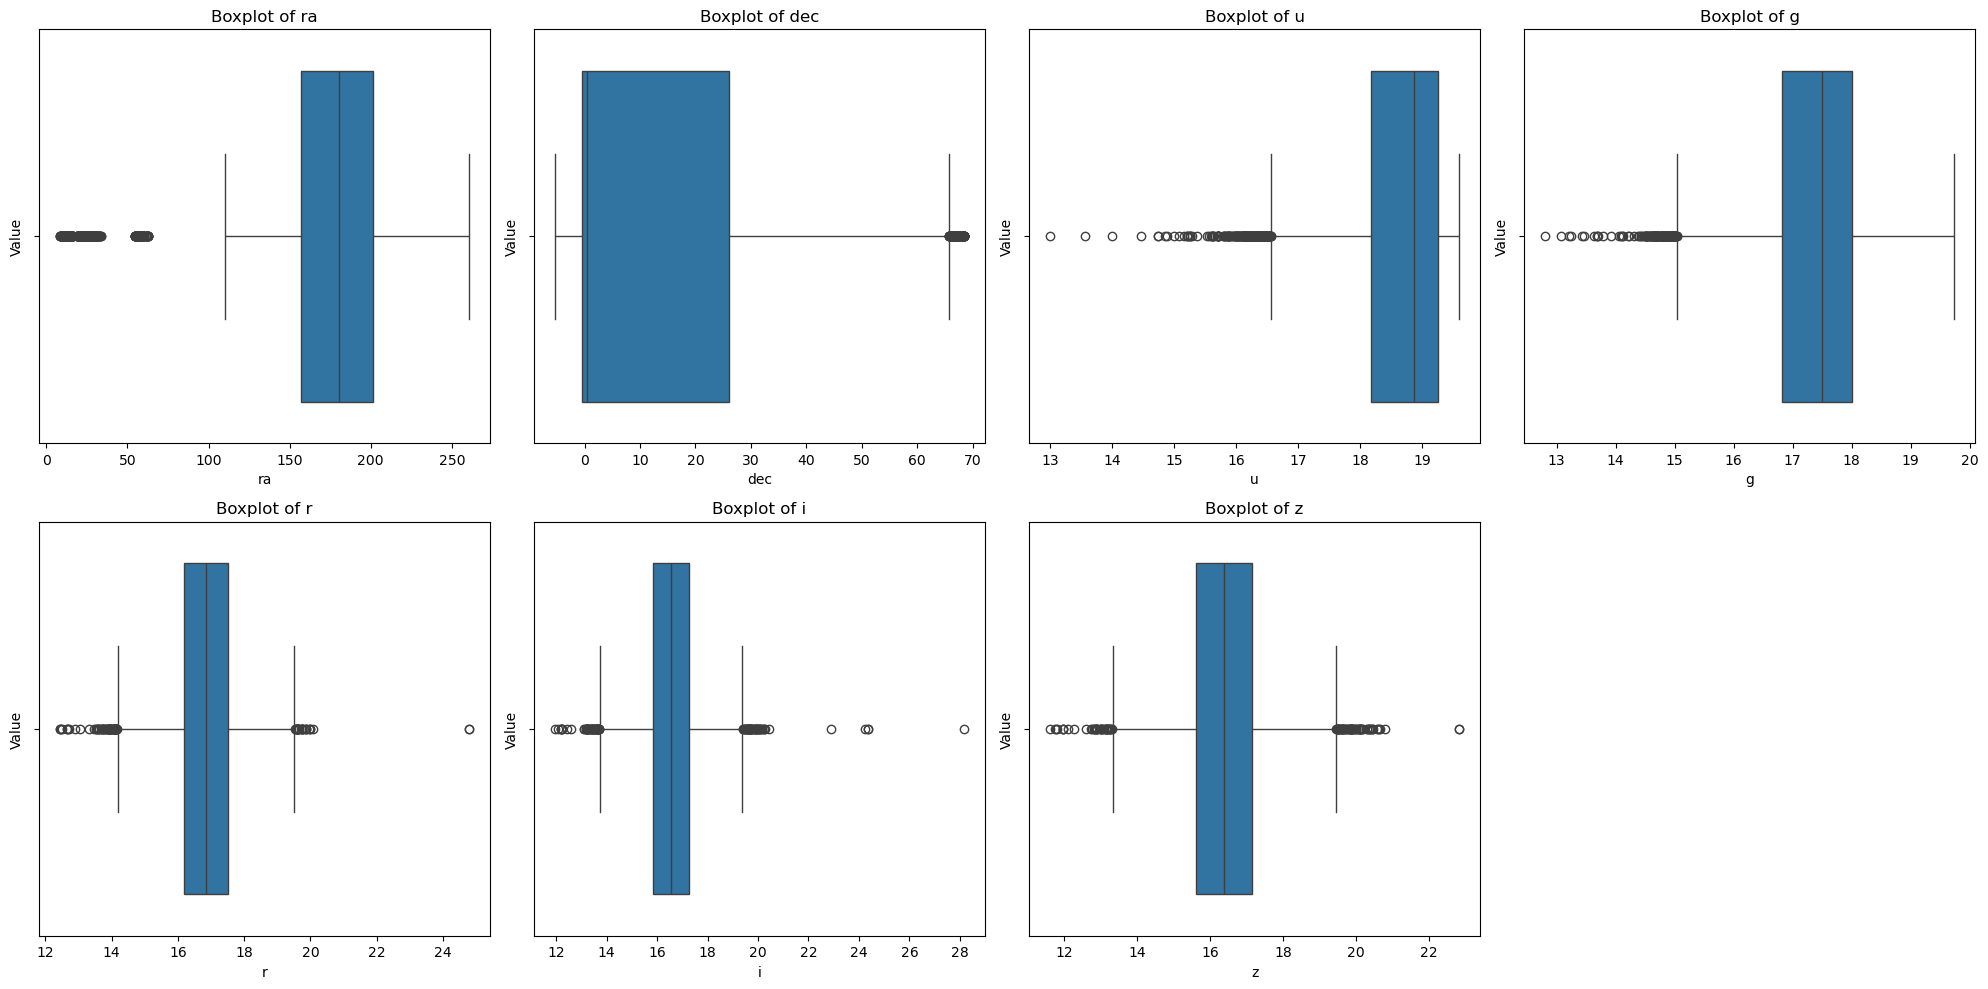

In [217]:
# boxplot for the features
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
# Plot boxplot for each feature
for i, feature in enumerate(features):
    sns.boxplot(data=df,x=feature,ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Value')
    
# Remove unused empty subplot
for j in range(len(features), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

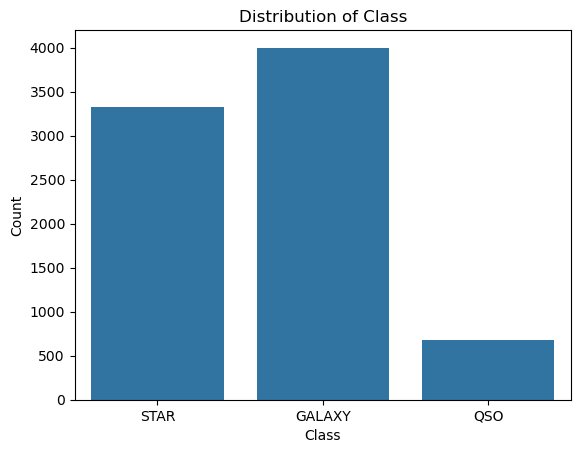

In [218]:
sns.countplot(x='class', data=df)
plt.title('Distribution of Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

The dataset contains outliers in photometric features, but these extreme values may represent rare astronomical objects such as quasars (QSO). Since quasars are naturally less frequent in the dataset, removing outliers directly could lead to the loss of important scientific information. Therefore, outliers will be handled carefully during further analysis and model training.

### Bivariate Exploratry Data Analysis

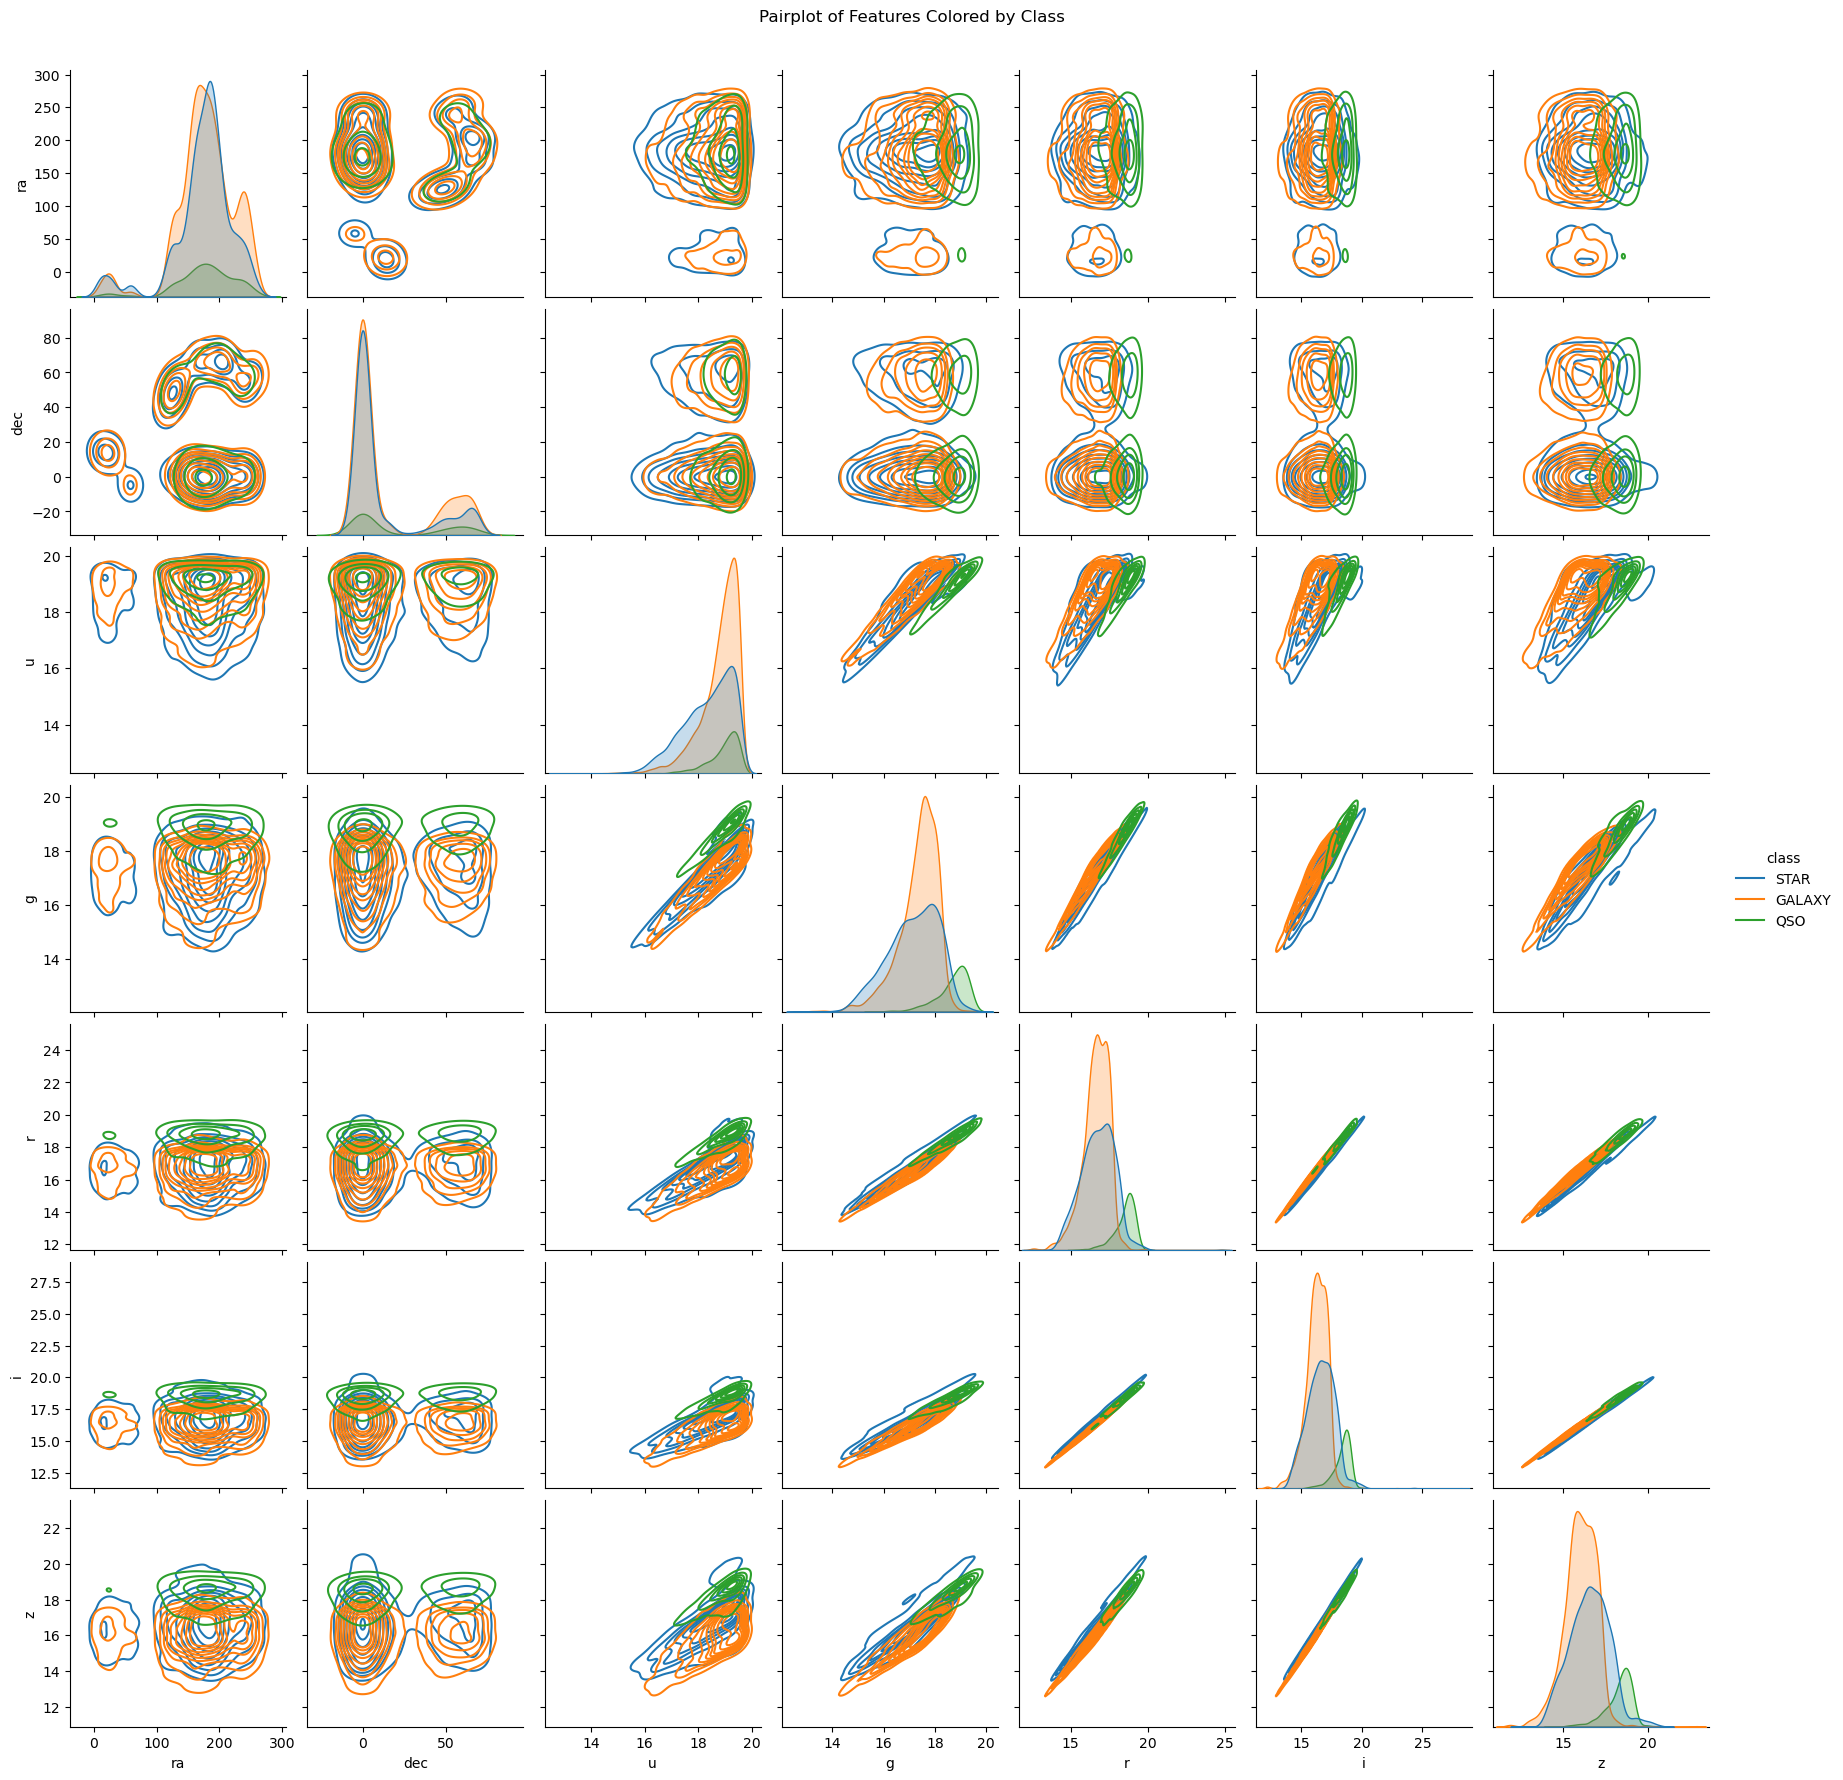

In [219]:
# Bivariate analysis using pairplot
sns.pairplot(df, hue='class', kind='kde')
plt.suptitle('Pairplot of Features Colored by Class', y=1.02)
plt.show()

The KDE pairplot shows strong relationships between the photometric bands ('u', 'g', 'r', 'i', 'z') and clear distribution differences among the object classes. Quasars (QSO) appear more separated in several photometric features, indicating that photometric information is useful for classification. The plots also reveal strong correlations between nearby photometric bands, suggesting multicollinearity in the dataset. In comparison, the coordinate features ('ra', 'dec') show weaker class separation.

### Feature Construction

In [251]:
# Creating color index features
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

df[['u_g', 'g_r', 'r_i', 'i_z']].head()

,u_g,g_r,r_i,i_z
0,0.89469,0.23441,0.09566,0.02002
1,1.38504,0.54803,0.22586,0.14752
2,1.78637,0.91668,0.48725,0.36071
3,1.23327,-0.08161,-0.09086,-0.07548
4,0.03541,0.24602,0.08033,-0.03672


Instead of using only raw photometric magnitudes, color-index features were created by calculating the difference between adjacent photometric bands. These color indices ('u-g', 'g-r', 'r-i', 'i-z') are astrophysically important because they provide information about the temperature, spectral properties, and true color of celestial objects. Such features are often more useful for astronomical classification tasks than raw magnitudes alone.

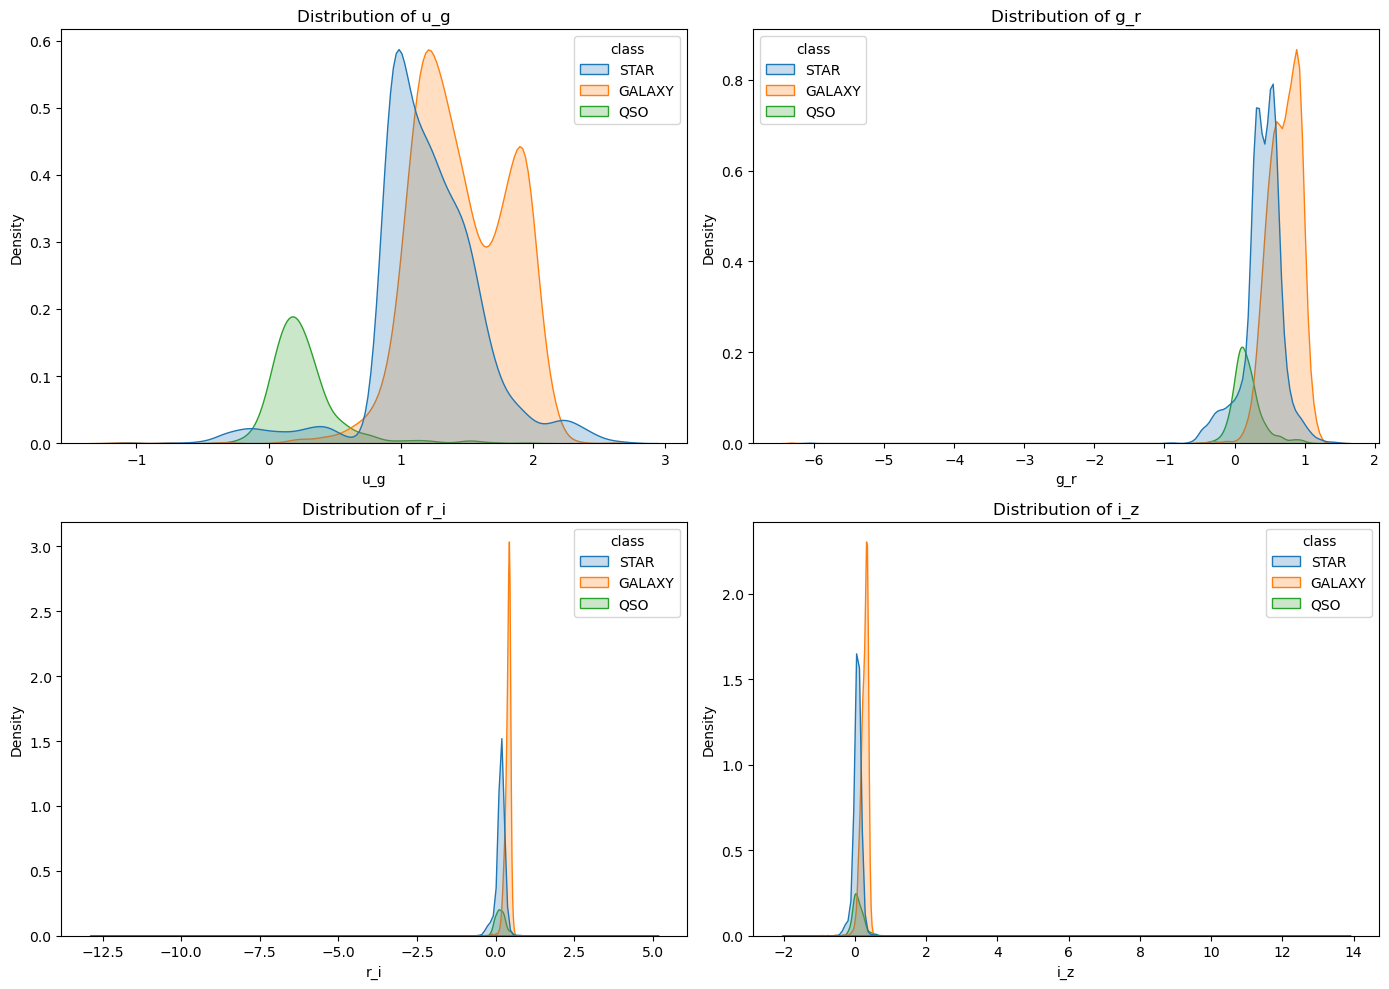

In [252]:
# Color index features
color_features = ['u_g', 'g_r', 'r_i', 'i_z']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plot distributions
for i, feature in enumerate(color_features):

    sns.kdeplot(
        data=df,
        x=feature,
        hue='class',
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

The distributions of the color-index features were analyzed for different object classes. Compared to the raw photometric magnitudes, the color indices show clearer class separation, especially for quasars (QSO). This indicates that color-based features capture important astrophysical information useful for distinguishing between stars, galaxies, and quasars.

In [253]:
df.head()

,ra,dec,u,g,r,i,z,class,u_g,g_r,r_i,i_z
0,172.905328,-1.539105,19.31536,18.42067,18.18626,18.09060,18.07058,STAR,0.89469,0.23441,0.09566,0.02002
1,162.006541,0.831897,19.29348,17.90844,17.36041,17.13455,16.98703,STAR,1.38504,0.54803,0.22586,0.14752
2,198.881267,0.407531,19.40578,17.61941,16.70273,16.21548,15.85477,GALAXY,1.78637,0.91668,0.48725,0.36071
3,179.700240,-0.589650,18.19151,16.95824,17.03985,17.13071,17.20619,STAR,1.23327,-0.08161,-0.09086,-0.07548
4,253.674045,61.671879,18.08931,18.05390,17.80788,17.72755,17.76427,QSO,0.03541,0.24602,0.08033,-0.03672


# Separating Features and Target

In [254]:
# Input features
X = df.drop(columns=['class'])
# Target variable
y = df['class']

print(X.shape)
print(y.shape)

(8000, 11)
(8000,)


In [255]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [256]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [257]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler

# Features for StandardScaler
standard_features = ["ra", "dec", "u", "g", "r","i", "z", "u_g", "g_r"]

# Features for RobustScaler
robust_features = ["r_i", "i_z"]

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("standard", StandardScaler(), standard_features),
        ("robust", RobustScaler(), robust_features)
    ],
    remainder="drop"
)

# Fit transformer on the training data
X_train_scaled = preprocessor.fit_transform(X_train)

# Transform the test data
X_test_scaled = preprocessor.transform(X_test)

Histogram analysis showed that most numerical features follow moderately continuous distributions and were standardized using 'StandardScaler'. However, the color-index features 'r_i' and 'i_z' contain concentrated distributions with noticeable outliers, so 'RobustScaler' was applied to reduce the influence of extreme values while preserving important astrophysical information.

In [258]:
# Convert transformed array into dataframe
scaled_columns = standard_features + robust_features

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=scaled_columns
)

X_train_scaled_df.describe()

,ra,dec,u,g,r,i,z,u_g,g_r,r_i,i_z
count,6.400000e+03,6.400000e+03,6.400000e+03,6.400000e+03,6.400000e+03,6.400000e+03,6.400000e+03,6.400000e+03,6.400000e+03,6400.000000,6400.000000
mean,-4.518608e-16,-5.662137e-17,7.910339e-18,-1.030842e-15,-1.720846e-15,2.293721e-15,6.827872e-17,1.976197e-16,-6.744605e-17,-0.044012,0.083140
std,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.000078e+00,1.072951,1.098763
min,-3.479042e+00,-7.990986e-01,-6.748572e+00,-4.819772e+00,-4.101846e+00,-3.939208e+00,-3.869437e+00,-4.809129e+00,-2.128767e+01,-52.159677,-8.832795
25%,-3.781803e-01,-6.057949e-01,-5.251058e-01,-5.750228e-01,-6.177154e-01,-6.352939e-01,-6.598757e-01,-4.730118e-01,-5.862061e-01,-0.466572,-0.376739
50%,1.190996e-01,-5.683906e-01,2.858210e-01,1.329133e-01,1.709359e-02,-2.477439e-02,-2.755987e-02,1.755391e-02,4.071507e-02,0.000000,0.000000
75%,5.450122e-01,4.542011e-01,7.689075e-01,6.657315e-01,6.232205e-01,5.962123e-01,5.988013e-01,6.234465e-01,7.018214e-01,0.533428,0.623261
max,1.786417e+00,2.152859e+00,1.175776e+00,2.496000e+00,7.427708e+00,1.011075e+01,5.319260e+00,2.930115e+00,2.958295e+00,18.955167,59.702456


# Logistic Regression Model

In [259]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create ML pipeline
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000,class_weight="balanced"))
])

In [260]:
# Train the pipeline
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standard', ...), ('robust', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [263]:
# Predict
y_pred = pipe.predict(X_test)
y_pred[:10]

array([0, 0, 2, 2, 0, 1, 0, 0, 2, 2])

In [265]:
# Evaluate the Logistic Regression model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.93

Classification Report:

              precision    recall  f1-score   support

      GALAXY       0.98      0.91      0.94       800
         QSO       0.78      0.95      0.86       136
        STAR       0.91      0.96      0.93       664

    accuracy                           0.93      1600
   macro avg       0.89      0.94      0.91      1600
weighted avg       0.93      0.93      0.93      1600



## Logistic Regression Discussion

The Logistic Regression model achieved an accuracy of 93%, showing strong performance in classifying stars, galaxies, and quasars using photometric features and color indices. The model also handled the imbalanced quasar class effectively with high recall.

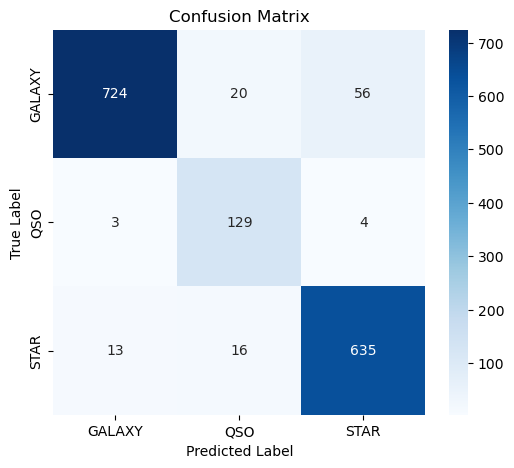

In [266]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the model correctly classifies most celestial objects, with only minor confusion between stars and galaxies due to similar photometric properties. Overall, the model demonstrates strong classification performance across all classes.

In [275]:
# cross validation using cross_val_score
from sklearn.model_selection import cross_val_score
cross_val_score(pipe, X_train, y_train, cv=10, scoring='accuracy').mean()

np.float64(0.9326562500000002)

The cross-validation accuracy of approximately 93% indicates that the model generalizes well across different data splits. The consistency between test accuracy and cross-validation accuracy suggests that the model is stable and does not show significant overfitting.

# Random Forest Model

In [271]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),

    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train model
rf_pipe.fit(X_train, y_train)

# Predictions
rf_y_pred = rf_pipe.predict(X_test)

In [272]:
# Evaluate the Random Forest model
print("Accuracy:", accuracy_score(y_test, rf_y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test,rf_y_pred,target_names=le.classes_))

Accuracy: 0.965

Classification Report:

              precision    recall  f1-score   support

      GALAXY       0.98      0.97      0.97       800
         QSO       0.91      0.91      0.91       136
        STAR       0.96      0.97      0.97       664

    accuracy                           0.96      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.97      0.96      0.97      1600



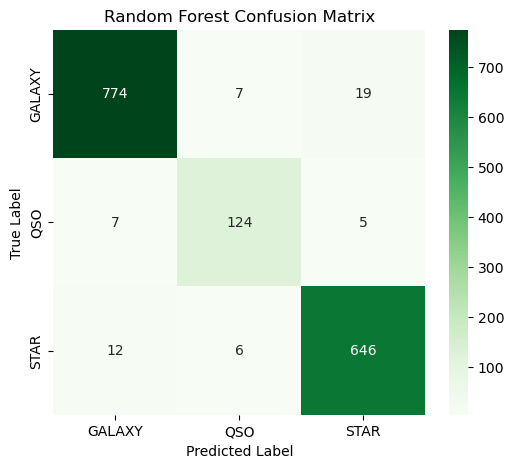

In [274]:
# Confusion matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_y_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [276]:
# cross validation using cross_val_score
cross_val_score(rf_pipe, X_train, y_train, cv=10, scoring='accuracy').mean()

np.float64(0.9637499999999999)

## Random Forest Discussion

The Random Forest model achieved an accuracy of approximately 96%, outperforming Logistic Regression in all major evaluation metrics. The model showed strong classification performance for stars, galaxies, and quasars, with reduced misclassification between object classes. The cross-validation accuracy also remained consistent, indicating that the model generalizes well and does not show significant overfitting.

# Feature Importance Analysis

In [280]:
# Extract trained Random Forest model
rf_model = rf_pipe.named_steps["model"]

# Feature names
feature_names = standard_features + robust_features

# Feature importance dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort values
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display
print(importance_df)

   Feature  Importance
7      u_g    0.262330
9      r_i    0.214891
10     i_z    0.143430
4        r    0.101382
8      g_r    0.082127
5        i    0.061169
3        g    0.045625
6        z    0.045001
2        u    0.025981
0       ra    0.009332
1      dec    0.008733


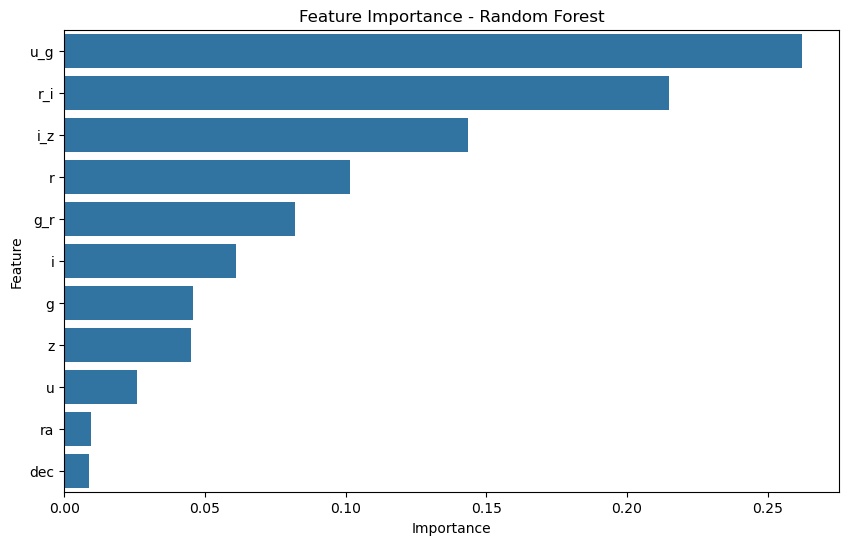

In [281]:
# Plot feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.show()

The feature importance analysis shows that color-index features contributed most to the classification process, confirming that photometric color information is highly effective for distinguishing stars, galaxies, and quasars.

## Model Comparison

Both models performed well on the stellar object classification task, but Random Forest achieved higher accuracy and better overall classification performance than Logistic Regression. Logistic Regression provided a strong baseline model, while Random Forest handled complex nonlinear relationships more effectively and reduced misclassification between object classes.

## Evaluation & Hidden Test Pipeline

In [282]:
def evaluate_hidden_data(hidden_data_url, model_pipe=rf_pipe, label_encoder=le):
    """
    Load a hidden CSV file from a GitHub raw link, create color features,
    predict classes using the trained pipeline, and display evaluation results.
    """
    
    # Load hidden dataset
    hidden_df = pd.read_csv(hidden_data_url)
    
    # Create color-index features
    hidden_df["u_g"] = hidden_df["u"] - hidden_df["g"]
    hidden_df["g_r"] = hidden_df["g"] - hidden_df["r"]
    hidden_df["r_i"] = hidden_df["r"] - hidden_df["i"]
    hidden_df["i_z"] = hidden_df["i"] - hidden_df["z"]
    
    # Check whether target column exists
    if "class" not in hidden_df.columns:
        raise ValueError("The hidden dataset does not contain a 'class' column.")
    
    # Separate features and target
    y_true = hidden_df["class"]
    X_hidden = hidden_df.drop(columns=["class"])
    
    # Encode true labels
    y_true_encoded = label_encoder.transform(y_true)
    
    # Predict
    y_pred = model_pipe.predict(X_hidden)
    
    # Evaluation
    print("Accuracy:", accuracy_score(y_true_encoded, y_pred))
    print("\nClassification Report:\n")
    print(classification_report(y_true_encoded, y_pred, target_names=label_encoder.classes_))
    
    # Confusion matrix
    cm = confusion_matrix(y_true_encoded, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Hidden Data Confusion Matrix")
    plt.show()

# Example usage:
# hidden_data_url = "PASTE_YOUR_GITHUB_RAW_CSV_LINK_HERE"
# evaluate_hidden_data(hidden_data_url)

A reusable evaluation function is created to test the trained model on any new hidden CSV file. The function automatically loads the data, creates the color-index features, applies the trained pipeline, and displays the final confusion matrix and classification report.